In [ ]:
# parameters for execution
PUBLIC_DATASET = 'impl_d'
nyst = False # True if you want nystrom sampling
landmarks = 700 # 700 for FPGA1 , 280 for FPGA2 and 180 for FPGA3

# EMSCA Analysis & Metrics

**Author:** Dev Mehta and Mohammad Nour

**Description:** Load captured EM traces, compute side-channel metrics (TVLA, CEMA, SNR), and prepare outputs for MATLAB PSO optimization.

## Imports and Parameters

In [ ]:
# Imports
import chipwhisperer as cw
import sys
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.stats import ttest_ind
from scipy.io import savemat

#adjust scapegoat path based on your local setup
sys.path.insert(1, './SCAPEgoat/') 

from WPI_SCA_LIBRARY.CWScope import *
from WPI_SCA_LIBRARY.LeakageModels import *
%run "./EMSCA_functions.ipynb"
%run "./AES_model.ipynb"

# Global Parameters
probe_diameter = "1.2mm"  # Same for all platforms

## Data Source Selection
Choose between loading from live capture experiments or pre-made public datasets.

In [2]:
# Initialize SCApeGoat experiment manager
emsca = FileParent("CEMA", "./", True)

# ===== SELECT DATA SOURCE =====
# DATA_SOURCE options:
#   - "CAPTURE": Load from locally captured SCApeGoat experiments
#   - "PUBLIC": Load from pre-captured public datasets (authors' reference)
DATA_SOURCE = "PUBLIC"  # Change to "CAPTURE" if using your own captured data

print(f"Data Source: {DATA_SOURCE}")

Data Source: PUBLIC


## Data Selection & Configuration

In [ ]:
if DATA_SOURCE == "CAPTURE":
    # ===== Configuration for Captured Data =====
    TARGET = "FPGA"  # Options: "FPGA" or "UC"
    BITFILE_NAME = "impl_3"  # specify the bitfile name
    n_steps = 10         # Grid size (10x10)
    N_traces = 10000     # Traces per grid position
    variant = BITFILE_NAME
    if TARGET == "FPGA":
        dut = "CW305"
        bitfile = f"{BITFILE_NAME}.bit"
        print(f"Target: FPGA (CW305)")
        print(f"Bitfile: {bitfile}")
    elif TARGET == "UC":
        dut = "CW-Lite"
        bitfile = None
        print(f"Target: Microcontroller (CW Lite)")
    
    print(f"Grid: {n_steps}x{n_steps}")
    print(f"Traces per position: {N_traces}")

elif DATA_SOURCE == "PUBLIC":
    # ===== Configuration for Public Datasets =====
    # Pre-captured and preprocessed reference datasets from authors
    # Available options: "impl_d" (default), "impl_3", "uc"
    # PUBLIC_DATASET = "impl_d"  # Change to "impl_d", or "uc" as needed
    PUBLIC_DATASET = PUBLIC_DATASET
    
    print(f"\nLoading public dataset: {PUBLIC_DATASET}")
    
    if PUBLIC_DATASET == "impl_d":
        test_avg = emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_default_avg_reduced')
        test_t = emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_default_avg_reduced_t')
        dut = "CW305"
        variant = "impl_d"
        TARGET = "FPGA"
        print(f"Loaded: FPGA default implementation")
    elif PUBLIC_DATASET == "impl_3":
        test_avg = emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_impl_3_avg_reduced')
        test_t = emsca.get_experiment('fpga_cema_1_2mm_10000_10x10_40x_impl_3_avg_reduced_t')
        dut = "CW305"
        variant = "impl_3"
        TARGET = "FPGA"
        print(f"Loaded: FPGA impl_3")
    elif PUBLIC_DATASET == "uc":
        test_avg = emsca.get_experiment('uc_cema_1_2mm_10000_10x10_30x_avg_a')
        test_t = emsca.get_experiment('uc_cema_1_2mm_10000_10x10_30x_avg_t')
        dut = "CW-Lite"
        variant = "uc"
        TARGET = "UC"
        print(f"Loaded: UC (microcontroller)")
    else:
        raise ValueError(f"Unknown PUBLIC_DATASET: {PUBLIC_DATASET}")
    
    N_traces = 1000  # Public datasets are pre-averaged/reduced
    n_steps = 10


Loading public dataset: impl_d
Loaded: FPGA default implementation


## Data Preprocessing (Optional)
The following preprocessing functions are available in CEMA_functions.ipynb for fresh CAPTURE data.
Public datasets are pre-processed and do not require these steps.

In [4]:
# Preprocessing functions are defined in CEMA_functions.ipynb
# Uncomment and use only for fresh CAPTURE data (not needed for PUBLIC datasets)

# =====AVERAGING: Reduces noise through trace averaging=====
# Pros: Significantly reduces noise in each grid position
# Cons: Reduces effective sample size (averaging N traces into 1)
# Use when: Traces are very noisy or computation is time-critical
# Example (uncomment to use with CAPTURE data):
#   if DATA_SOURCE == "CAPTURE":
#       test_avg = test_to_avg(test, test_copy, avg=10, grid_size=(n_steps, n_steps))

# ===== RANDOM SAMPLING: Maintains trace diversity =====
# Pros: Maintains diversity; faster than averaging for large datasets
# Cons: Less noise reduction than averaging; still reduces sample size
# Use when: You want to balance noise reduction with sample diversity
# Example (uncomment to use with CAPTURE data):
#   if DATA_SOURCE == "CAPTURE":
#       test_avg = test_to_randomsample(test, test_copy, n_samples=30, grid_size=(n_steps, n_steps))

# NOTE: Public datasets (impl_d, impl_3, uc) are already pre-processed.
# The _reduced and _avg variants already have averaging applied.
print("Preprocessing options available in CEMA_functions.ipynb")

Preprocessing options available in CEMA_functions.ipynb


## Load Data from Experiments or Files

In [5]:
if DATA_SOURCE == "CAPTURE":
    # ===== Load from SCApeGoat Experiments (CAPTURE) =====
    # Build experiment name matching capture notebook output
    experiment_name = f"{TARGET.lower()}_{probe_diameter.replace('.', '').replace('mm', '')}_{N_traces}_{n_steps}x{n_steps}"
    
    try:
        test = emsca.get_experiment(experiment_name)
        print(f"Loaded experiment: {experiment_name}")
        print(f"Shape: {test.data.shape}")
    except Exception as e:
        print(f"ERROR: Could not load experiment '{experiment_name}'")
        print(f"Available experiments: {list(emsca.experiments.keys())}")
        raise

elif DATA_SOURCE == "PUBLIC":
    # ===== Public Datasets Already Loaded =====
    # SCApeGoat experiments were loaded in the configuration cell above
    # (test, test_avg, test_t are now available)
    print(f"\nPublic dataset configuration complete.")
#     print(f"  Test set: {test.name}")
    print(f"  Avg set:  {test_avg.name}")
    print(f"  T-test set: {test_t.name}")
    print(f"  DUT: {dut}, Variant: {variant}")


Public dataset configuration complete.
  Avg set:  fpga_cema_1_2mm_10000_10x10_40x_default_avg_reduced
  T-test set: fpga_cema_1_2mm_10000_10x10_40x_default_avg_reduced_t
  DUT: CW305, Variant: impl_d


## Load Plaintext/Key Data

In [6]:
# Select which PT/keys experiment to use
# Options: 'pt_keys' (default), 'pt_keys_5k_rambus', 'pt_keys_5kx10_rambus'
PT_SELECTION = 'pt_keys_5k_rambus'  # change to 'pt_keys_5k_rambus' or 'pt_keys_5kx10_rambus' if needed


# Resolve experiment
try:
    if PT_SELECTION == 'pt_keys_5k_rambus':
        pt = emsca.get_experiment('pt_keys_5k_rambus')
    else:
        raise ValueError(f"Unknown PT_SELECTION: {PT_SELECTION}")
except Exception as e:
    print(f"WARNING: could not load selected PT experiment '{PT_SELECTION}': {e}")
    pt = None
    
#only used for manual computation
# if pt is None:
#     print("WARNING: Plaintext/Keys experiment not available. Some metrics may fail.")
#     pt = None
#     keys = None
# else:
#     # Read the standard datasets (same loading pattern used previously)
#     try:
#         keys_pt = pt.get_dataset('keys').read_data(0, 10000)
#     except Exception:
#         keys_pt = None
#     try:
#         random_pt = pt.get_dataset('plaintexts').read_data(0, 10000)
#     except Exception:
#         random_pt = None
#     try:
#         fixed_pt = pt.get_dataset('fixed_pt').read_data(0, 10000)
#     except Exception:
#         fixed_pt = None

#     print(f"Loaded PT experiment: {pt.name}")
#     print(f"  keys: {None if keys_pt is None else keys_pt.shape}")
#     print(f"  random plaintexts: {None if random_pt is None else random_pt.shape}")
#     print(f"  fixed plaintexts: {None if fixed_pt is None else fixed_pt.shape}")

## Compute Metrics: TVLA (t-statistic)

In [7]:
# Determine rotation_n based on target
#this is based on the how the device was palced for capturing and how you want to visualize the data
if TARGET == "FPGA":
    rotation_n = 2
else:  # UC
    rotation_n = 3

print(f"Rotation parameter: rotation_n={rotation_n} (TARGET={TARGET})")

Rotation parameter: rotation_n=2 (TARGET=FPGA)


Computing TVLA t-statistic heatmap...


Calculating T-Test:   0%|          | 0/1000 [00:00<?, ?it/s]D:\ChipWhisperer5_64\cw\home\portable\chipwhisperer\EMSCA\CEMA\../../SCApeGoat-main\WPI_SCA_LIBRARY\Metrics.py:161: RuntimeWarning: invalid value encountered in divide
  welsh_t = np.array(new_mr - new_mf) / np.sqrt(
Calculating T-Test: 100%|██████████| 1000/1000 [00:00<00:00, 24715.41it/s]


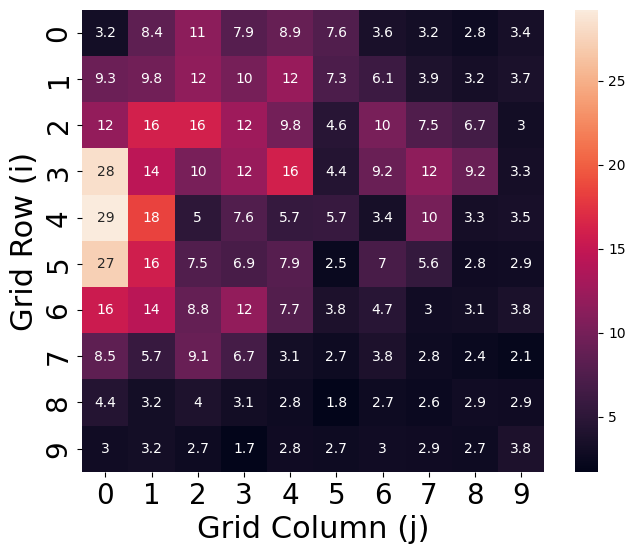

TVLA computation complete
t-statistic shape: 10
Max t-value: 29.22


In [8]:
# Compute TVLA (Welch's t-test) heatmap across grid
print("Computing TVLA t-statistic heatmap...")

t_values,tvla_fig = plot_t_statistic_heatmap(test_t, grid_size=n_steps, rotation_n=rotation_n)

print(f"TVLA computation complete")
print(f"t-statistic shape: {len(t_values)}")
print(f"Max t-value: {np.nanmax(np.abs(t_values)):.2f}")

# MI Computation

In [9]:
labels = np.load('labels_13.npy', allow_pickle=True)
labels_uc = np.load('uc_labels.npy', allow_pickle=True)


Processing grid position (0, 0)
Processing grid position (0, 1)
Processing grid position (0, 2)
Processing grid position (0, 3)
Processing grid position (0, 4)
Processing grid position (0, 5)
Processing grid position (0, 6)
Processing grid position (0, 7)
Processing grid position (0, 8)
Processing grid position (0, 9)
Processing grid position (0, 10)
Processing grid position (1, 0)
Processing grid position (1, 1)
Processing grid position (1, 2)
Processing grid position (1, 3)
Processing grid position (1, 4)
Processing grid position (1, 5)
Processing grid position (1, 6)
Processing grid position (1, 7)
Processing grid position (1, 8)
Processing grid position (1, 9)
Processing grid position (1, 10)
Processing grid position (2, 0)
Processing grid position (2, 1)
Processing grid position (2, 2)
Processing grid position (2, 3)
Processing grid position (2, 4)
Processing grid position (2, 5)
Processing grid position (2, 6)
Processing grid position (2, 7)
Processing grid position (2, 8)
Proces

D:\ChipWhisperer5_64\cw\home\portable\WPy64-31080\python-3.10.8.amd64\lib\site-packages\scipy\signal\_signaltools.py:1629: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)
D:\ChipWhisperer5_64\cw\home\portable\WPy64-31080\python-3.10.8.amd64\lib\site-packages\scipy\signal\_signaltools.py:1629: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)


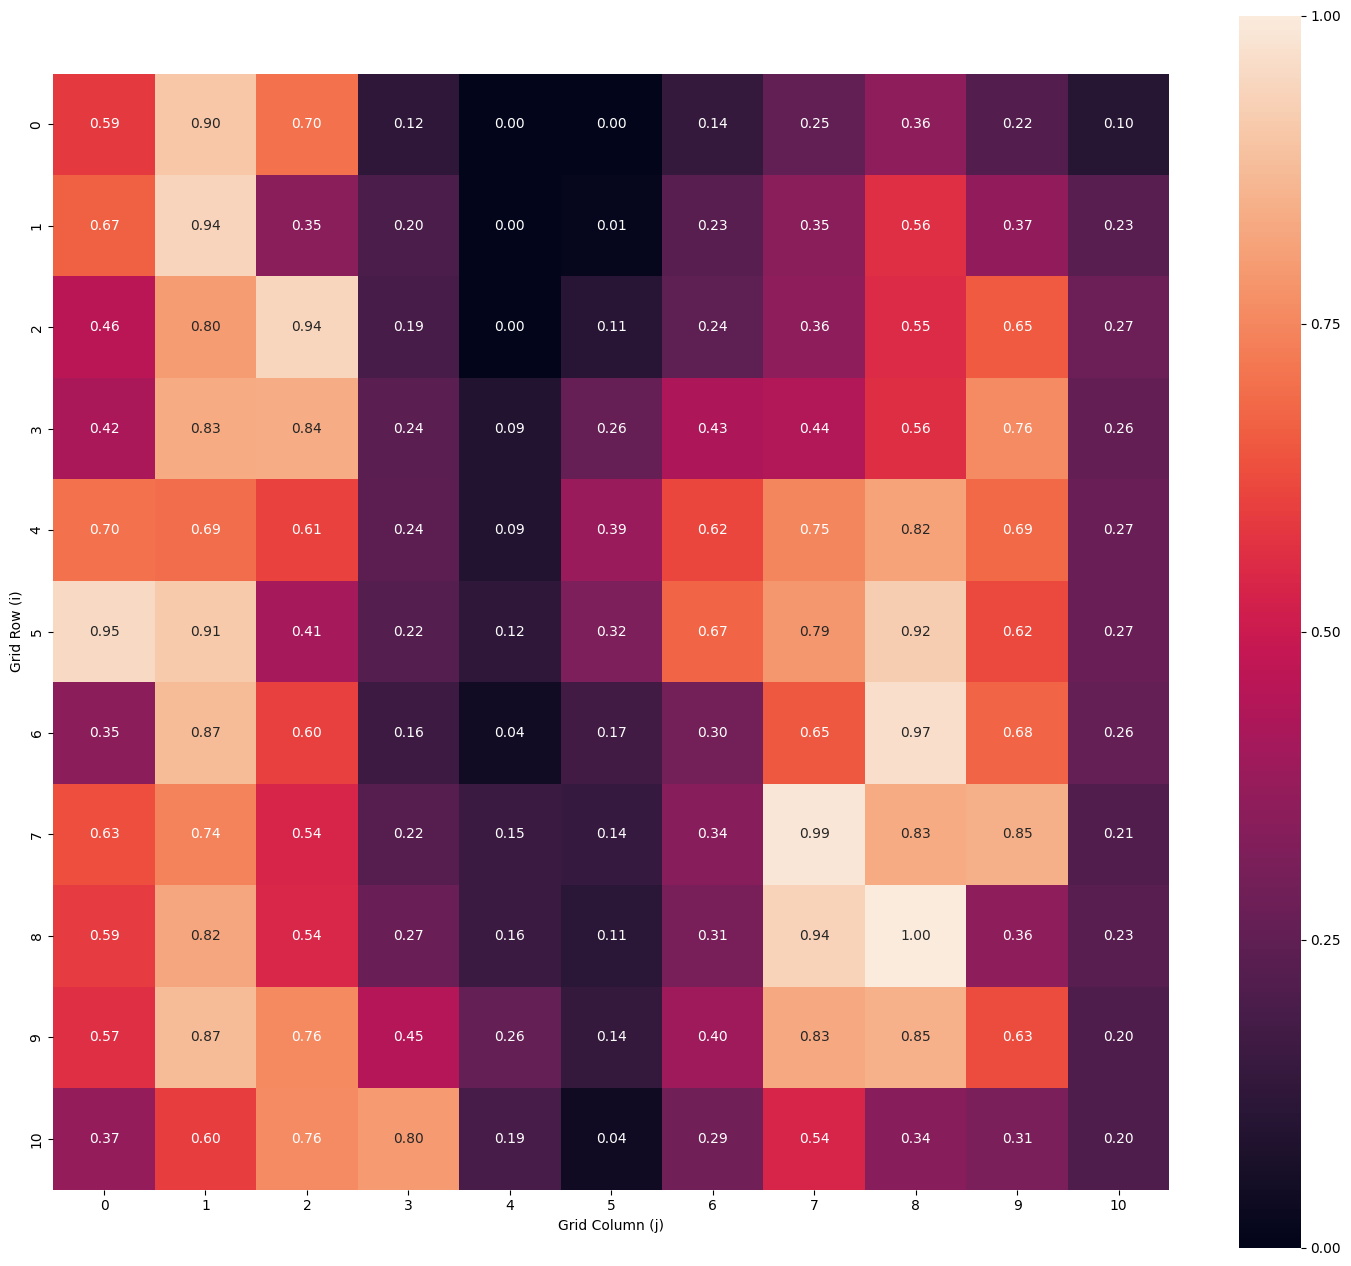

In [ ]:
num = 1000
nyst = nyst
landmarks = landmarks # 700 for FPGA1 , 280 for FPGA2 and 180 for FPGA3
grid_size = 11


lower_b = 0 # 5613 if the test is uc
upper_b = 1000 # 6063  if the test is uc
MI_final , HX_final = MI_heatmap(test_t,labels , num ,nyst, landmarks , grid_size=grid_size,rotation_n = rotation_n ,lower_b = lower_b,upper_b = upper_b)


## Results Summary

In [11]:
# Summary of computed metrics
print("\n" + "="*60)
print("ANALYSIS SUMMARY")
print("="*60)
print(f"Target: {TARGET} ({dut})")
if TARGET == "FPGA":
    if DATA_SOURCE == "CAPTURE":
        print(f"Bitfile: {bitfile}")
print(f"Data Source: {DATA_SOURCE}")
print(f"Grid Size: {n_steps}x{n_steps}")
print(f"Traces per Position: {N_traces}")
print(f"\nMetric Summary:")
print(f"  TVLA (max |t|):  {np.nanmax(np.abs(t_values)):.2f}")
print(f"  MI (max):        {np.nanmax(MI_final):.4f}")
print(f"\nResults ready for export to MATLAB.")
print("="*60)


ANALYSIS SUMMARY
Target: FPGA (CW305)
Data Source: PUBLIC
Grid Size: 10x10
Traces per Position: 1000

Metric Summary:
  TVLA (max |t|):  29.22
  MI (max):        1.0000

Results ready for export to MATLAB.


## Export Matrices for MATLAB
Save metric matrices in .mat format for PSO optimization.

In [12]:
# Create export directory
import os
export_dir = "./MATLAB_exports/"
os.makedirs(export_dir, exist_ok=True)

# Build filename pattern
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
file_prefix = f"{TARGET}_{variant}_{n_steps}x{n_steps}_{N_traces}traces_{timestamp}"

# Save MI matrix (primary input for PSO optimization)
mi_filename = os.path.join(export_dir, f"MI_{file_prefix}.mat")
savemat(mi_filename, {'MI': MI_final})
print(f"Saved MI matrix: {mi_filename}")

# Save other metrics for reference (optional)
tvla_filename = os.path.join(export_dir, f"TVLA_tstat_{file_prefix}.mat")
savemat(tvla_filename, {'t_values': t_values})
print(f"Saved TVLA t-statistic: {tvla_filename}")


print(f"\nExport directory: {os.path.abspath(export_dir)}")
print("Note: MI matrix is the primary input for MATLAB PSO optimization.")

Saved MI matrix: ./MATLAB_exports/MI_FPGA_impl_d_10x10_1000traces_20260507_2205.mat
Saved TVLA t-statistic: ./MATLAB_exports/TVLA_tstat_FPGA_impl_d_10x10_1000traces_20260507_2205.mat

Export directory: D:\ChipWhisperer5_64\cw\home\portable\chipwhisperer\EMSCA\CEMA\MATLAB_exports
Note: MI matrix is the primary input for MATLAB PSO optimization.


## Generate dataset for Matlab GMM 

In [13]:
# Build a trace matrix for downstream GMM / MI experiments.
# UC exports a fixed time window; FPGA exports the full trace.

TRACE_EXPORT_DATASET = "impl_d"  # options: "impl_d", "impl_3", "uc"
num_trace_to_save = 100
uc_trace_start = 5613
uc_trace_stop = 6063
grid_size = 11
output_csv = os.path.join(export_dir, f"data_100_121_{TRACE_EXPORT_DATASET}.csv")

source_experiment = test_t
trace_start = None
trace_stop = None
trace_blocks = []
for i in range(grid_size):
    for j in range(grid_size):
        print(f"Collecting random_{i}_{j}")
        traces = source_experiment.get_dataset(f"random_{i}_{j}").read_data(0, num_trace_to_save)
        if trace_start is None or trace_stop is None:
            trace_blocks.append(traces)
        else:
            trace_blocks.append(traces[:, trace_start:trace_stop])

trace_matrix = np.concatenate(trace_blocks, axis=0)
np.savetxt(output_csv, trace_matrix, delimiter=',')
print(f"Saved {trace_matrix.shape} to {output_csv}")

Saved (12100, 450) to ./MATLAB_exports/data_100_121_impl_d.csv


## Next Steps
Use the exported .mat files with the MATLAB PSO script.

In [14]:
print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"\nExported files ready for MATLAB:")
print(f"  1. {os.path.basename(mi_filename)}")
print(f"  2. {os.path.basename(tvla_filename)}")
print(f"  3. {os.path.basename(output_csv)}")
print(f"\nLocation: {os.path.abspath(export_dir)}")
print(f"\nNext: run `GMM_gen.m` using the exported CSV file, then run `PSO.m` using the exported MI file and the generated GMM model.")
print(f"\nAfter PSO: return here if you want to calculate CPA for a particular location.")

print("="*60)


ANALYSIS COMPLETE

Exported files ready for MATLAB:
  1. MI_FPGA_impl_d_10x10_1000traces_20260507_2205.mat
  2. TVLA_tstat_FPGA_impl_d_10x10_1000traces_20260507_2205.mat
  3. data_100_121_impl_d.csv

Location: D:\ChipWhisperer5_64\cw\home\portable\chipwhisperer\EMSCA\CEMA\MATLAB_exports

Next: run `GMM_gen.m` using the exported CSV file, then run `PSO.m` using the exported MI file and the generated GMM model.

After PSO: return here if you want to calculate CPA for a particular location.


## After PSO: CPA Traces at Specific Location
Visualize correlation traces at a specific grid position to inspect leakage patterns.


Analyzing CPA traces for FPGA
Coordinates: [(6, 5)]
Grid size: (11, 11)
Rotation parameter: 2

  Byte  0 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:03<00:00, 318.79it/s] 

0
Shape of maxcpa_matrix: (100, 256)


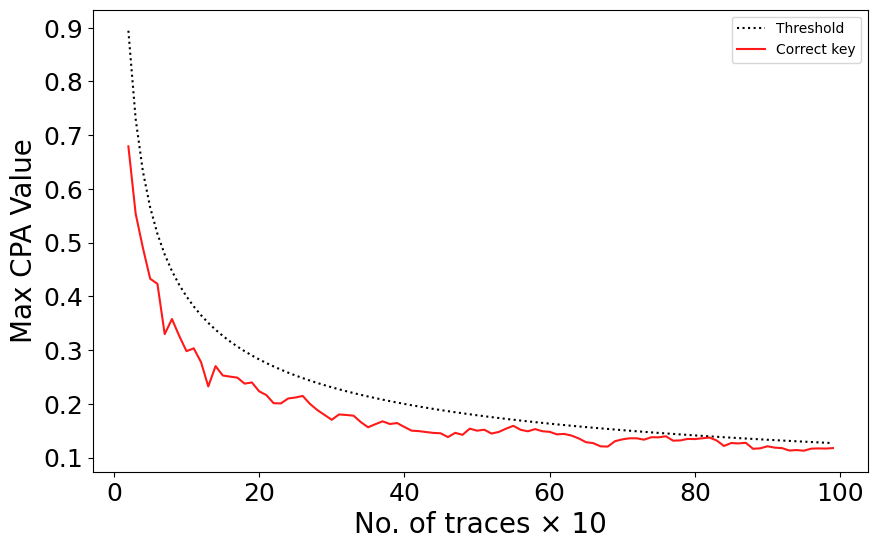

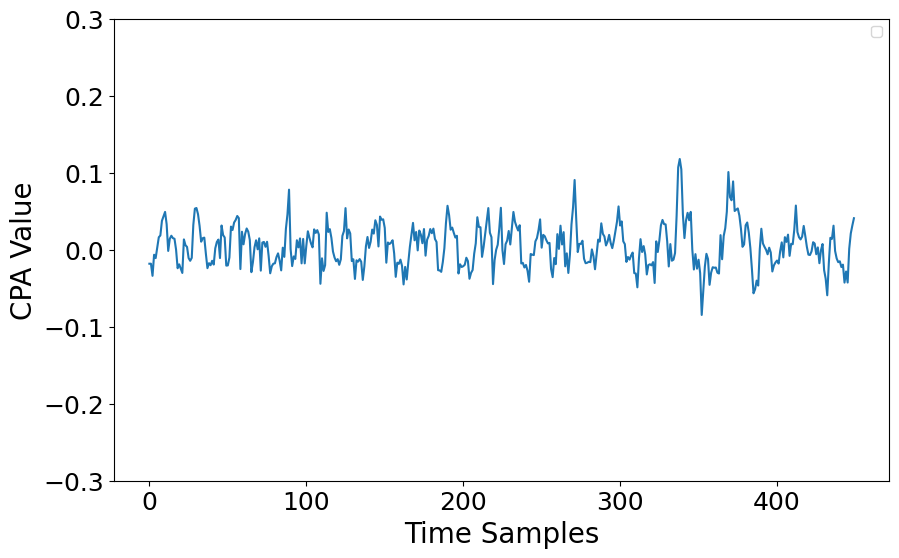

⚠️ CPA never stays permanently above the threshold.
Min traces: N/A
  Byte  1 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:02<00:00, 357.22it/s] 


1
Shape of maxcpa_matrix: (100, 256)


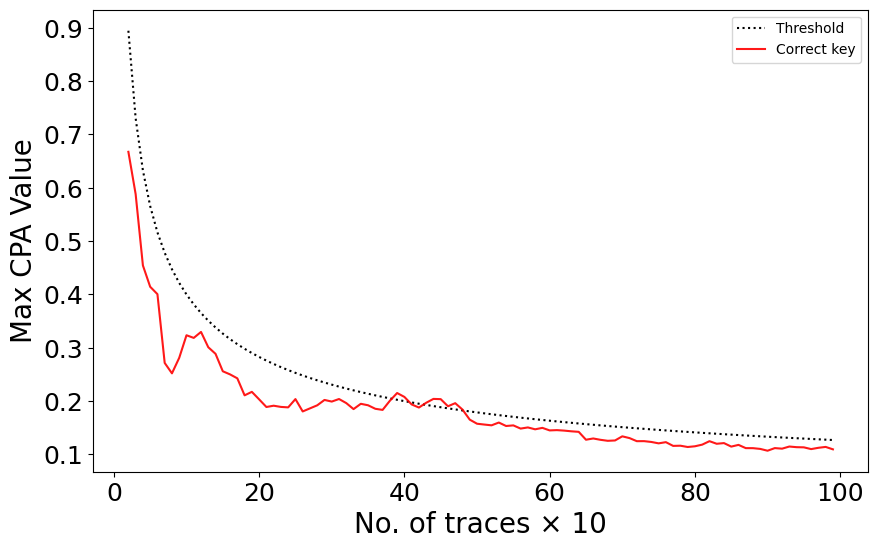

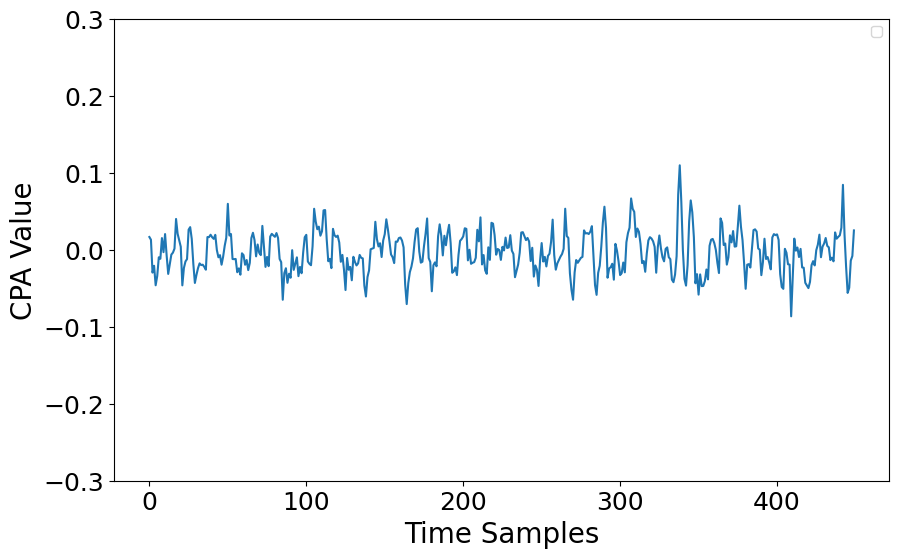

⚠️ CPA never stays permanently above the threshold.
Min traces: N/A
  Byte  2 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:02<00:00, 349.52it/s] 

2
Shape of maxcpa_matrix: (100, 256)


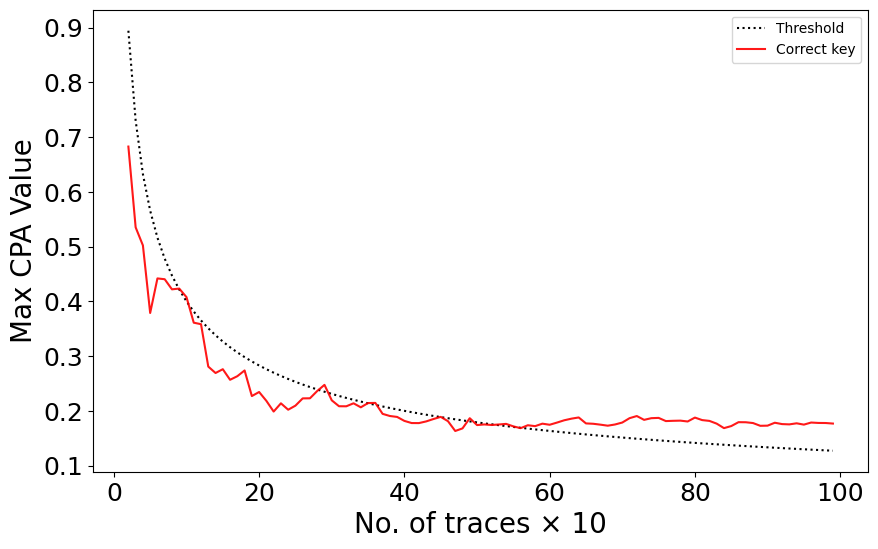

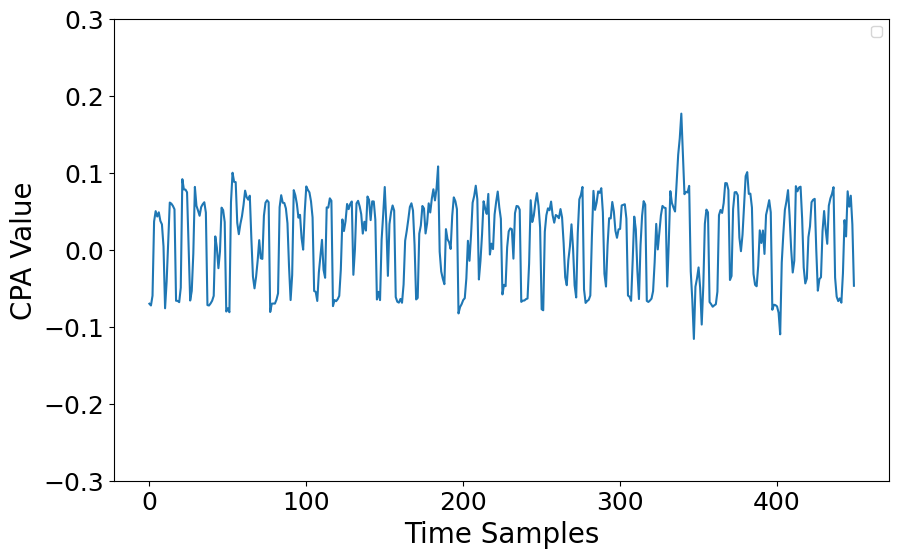

✅ CPA crosses threshold permanently at index 55 (≈ 570 traces)
Min traces: 570
  Byte  3 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:03<00:00, 255.85it/s] 

3
Shape of maxcpa_matrix: (100, 256)


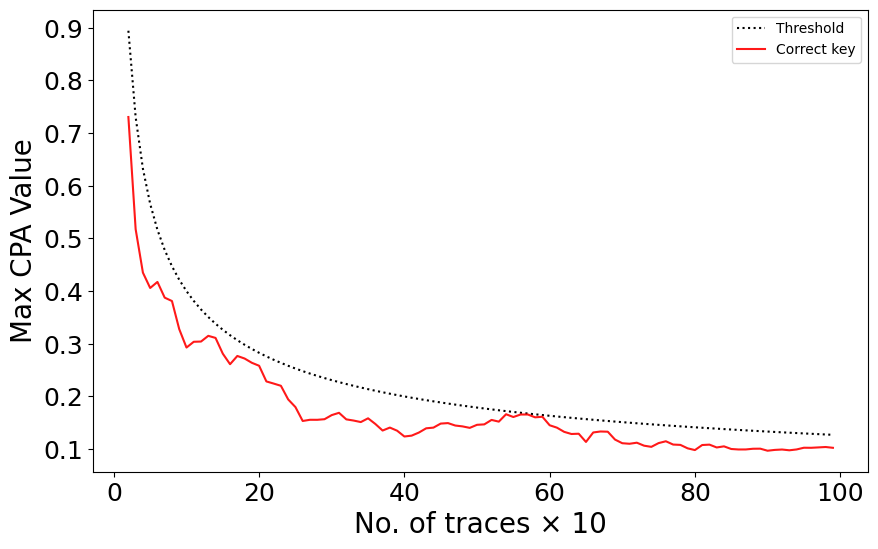

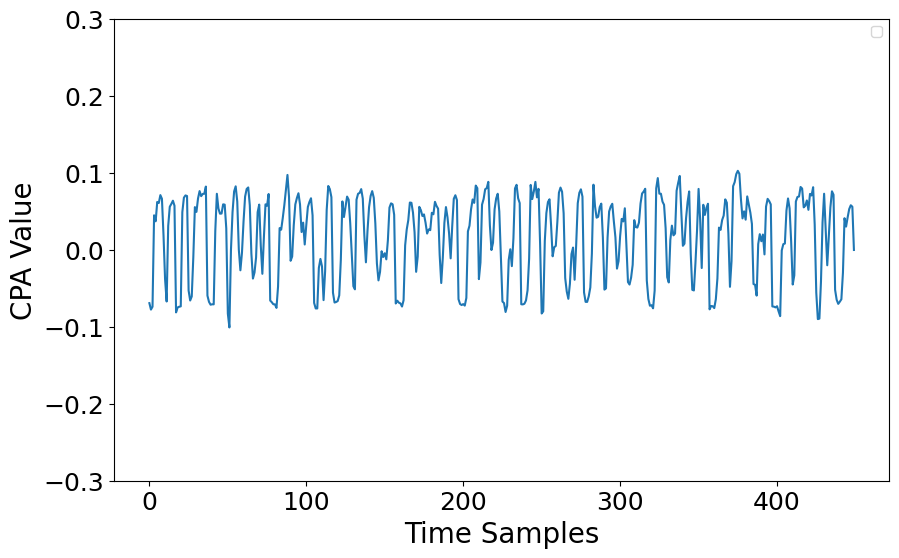

⚠️ CPA never stays permanently above the threshold.
Min traces: N/A
  Byte  4 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:03<00:00, 312.57it/s] 


4
Shape of maxcpa_matrix: (100, 256)


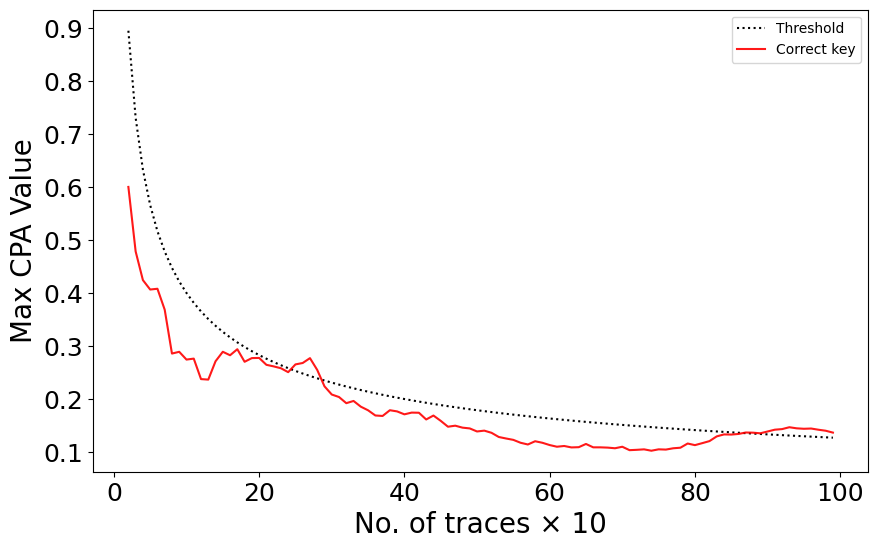

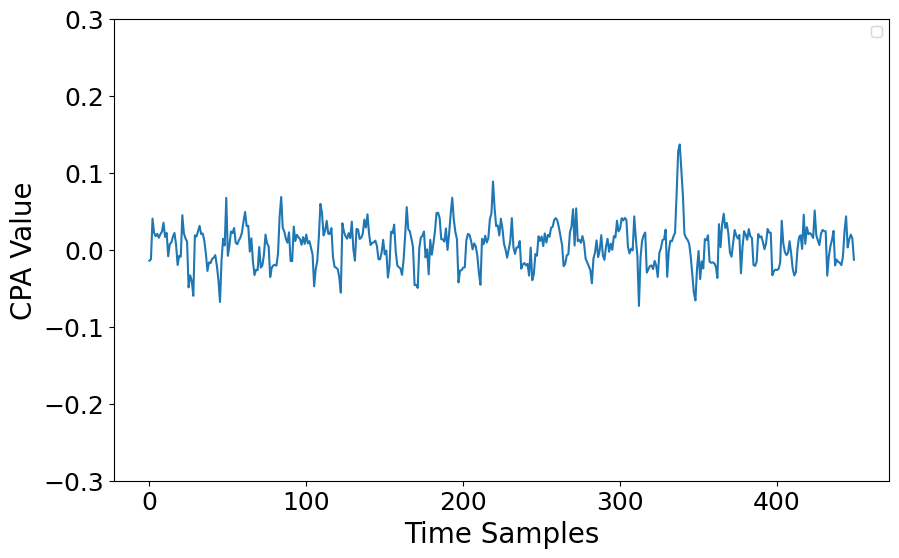

✅ CPA crosses threshold permanently at index 85 (≈ 870 traces)
Min traces: 870
  Byte  5 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:03<00:00, 279.90it/s] 

5
Shape of maxcpa_matrix: (100, 256)


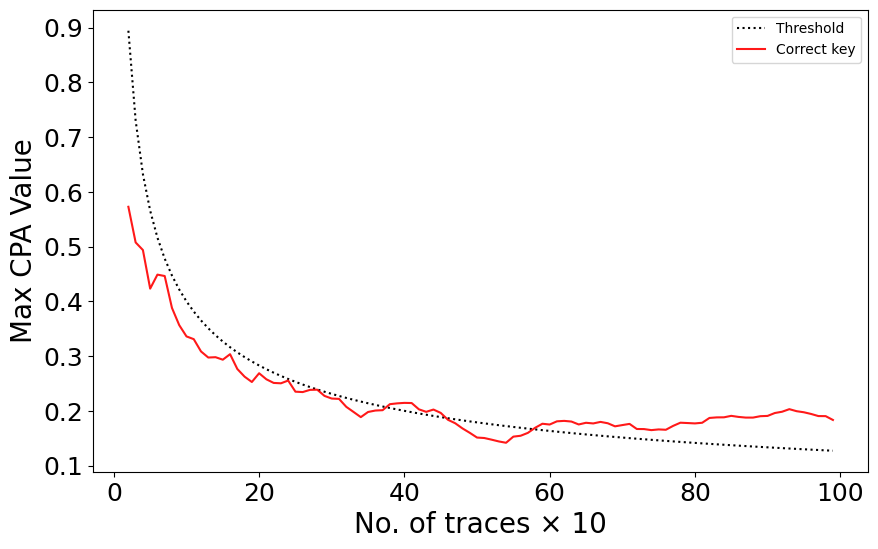

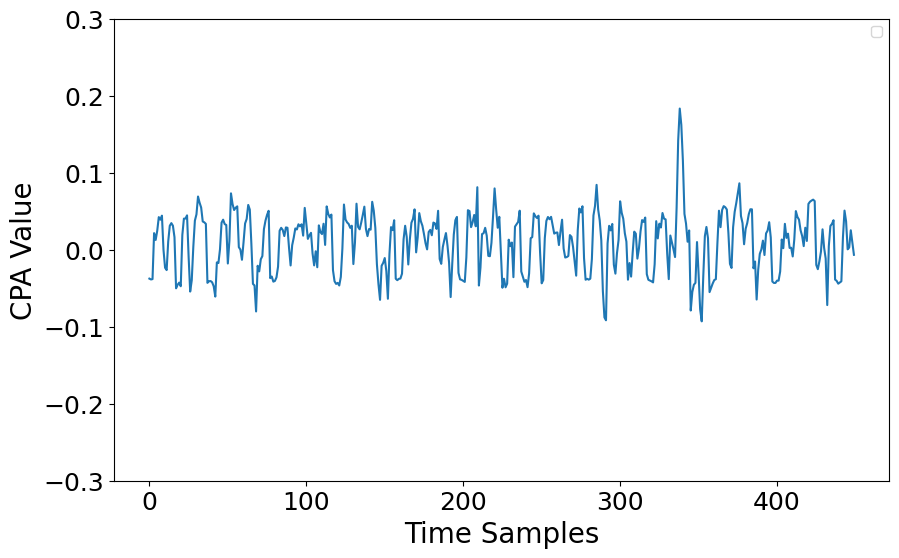

✅ CPA crosses threshold permanently at index 56 (≈ 580 traces)
Min traces: 580
  Byte  6 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:02<00:00, 356.81it/s] 

6
Shape of maxcpa_matrix: (100, 256)


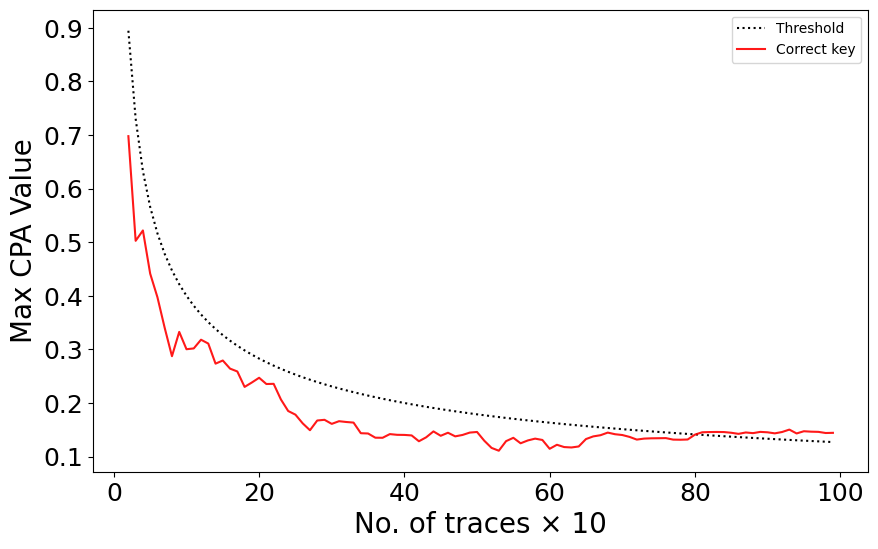

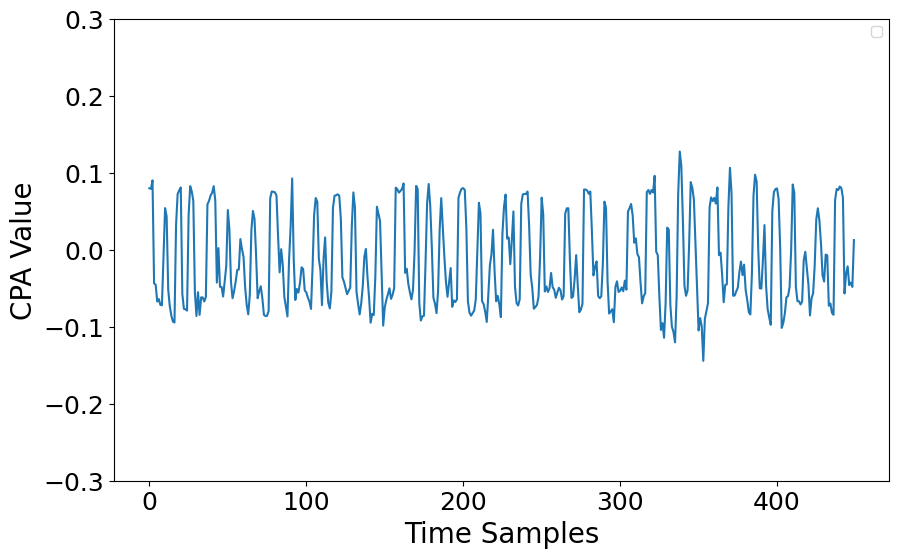

✅ CPA crosses threshold permanently at index 79 (≈ 810 traces)
Min traces: 810
  Byte  7 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:02<00:00, 356.72it/s] 


7
Shape of maxcpa_matrix: (100, 256)


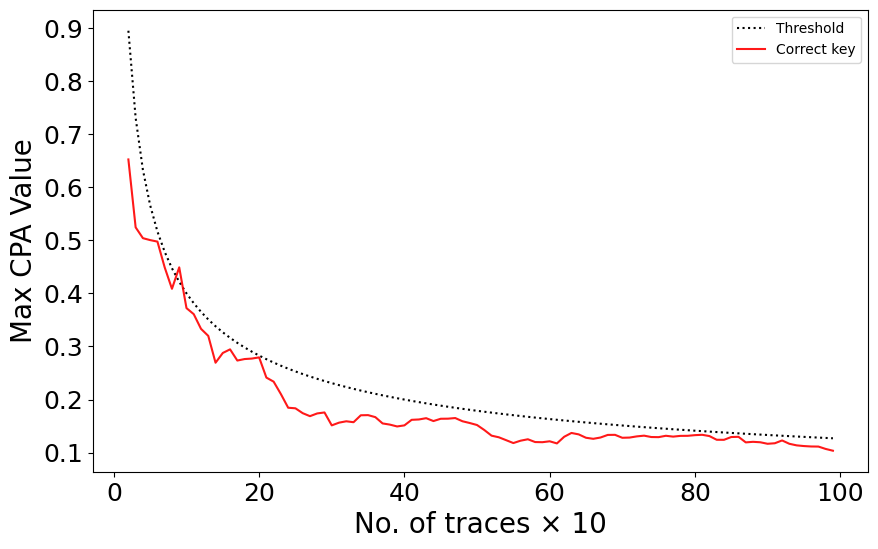

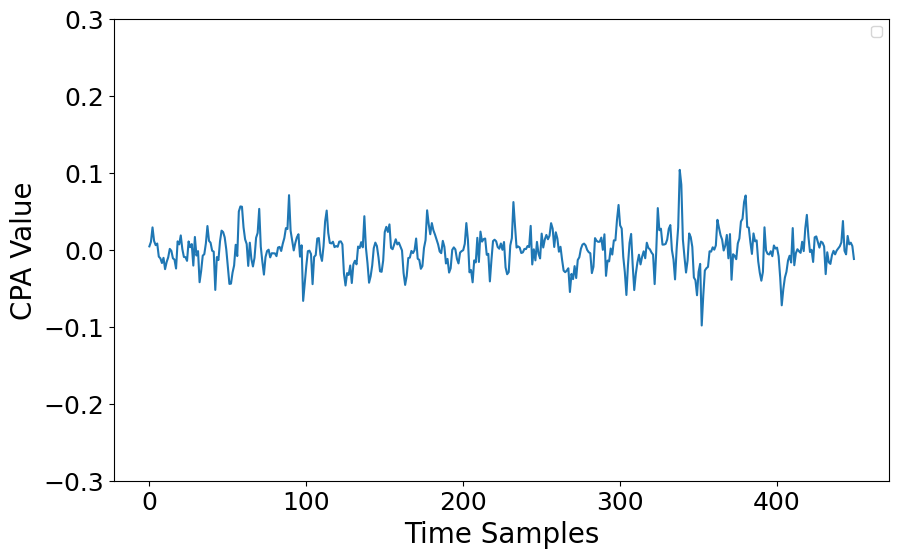

⚠️ CPA never stays permanently above the threshold.
Min traces: N/A
  Byte  8 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:02<00:00, 359.49it/s] 


8
Shape of maxcpa_matrix: (100, 256)


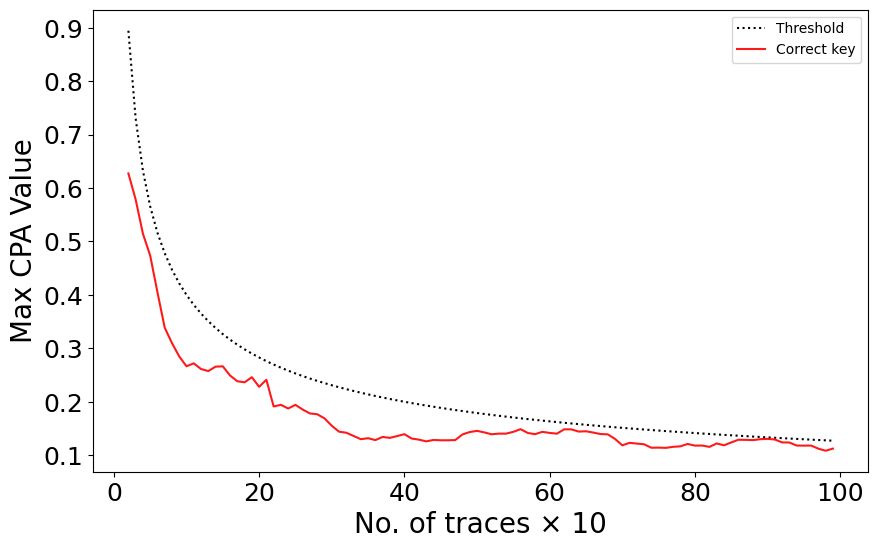

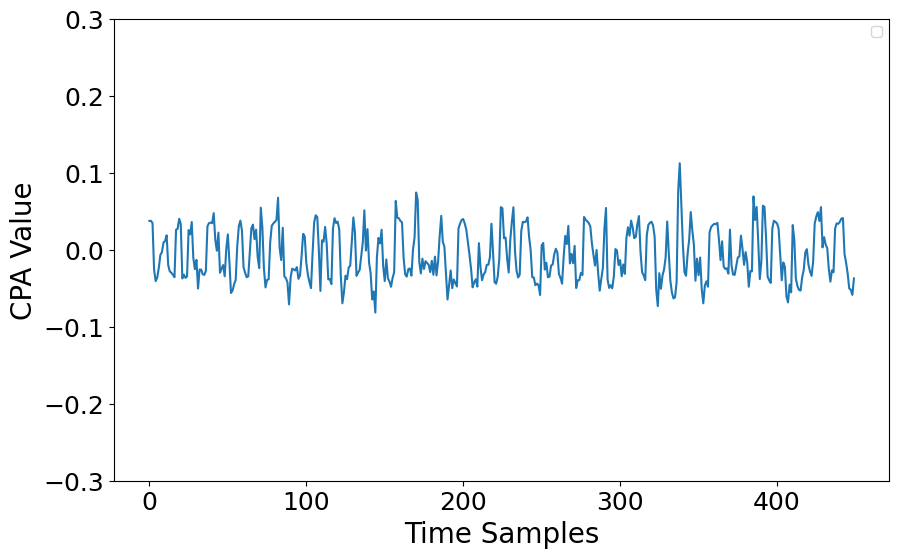

⚠️ CPA never stays permanently above the threshold.
Min traces: N/A
  Byte  9 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:02<00:00, 366.18it/s] 

9
Shape of maxcpa_matrix: (100, 256)


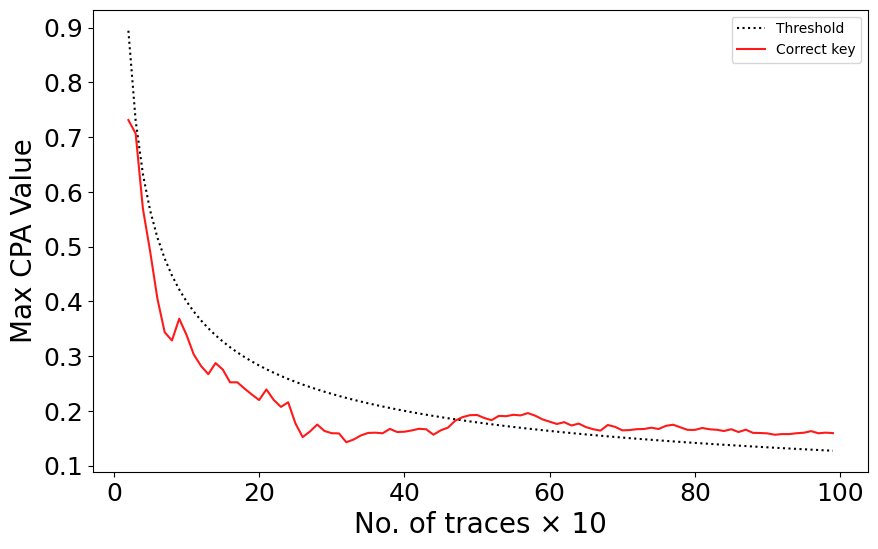

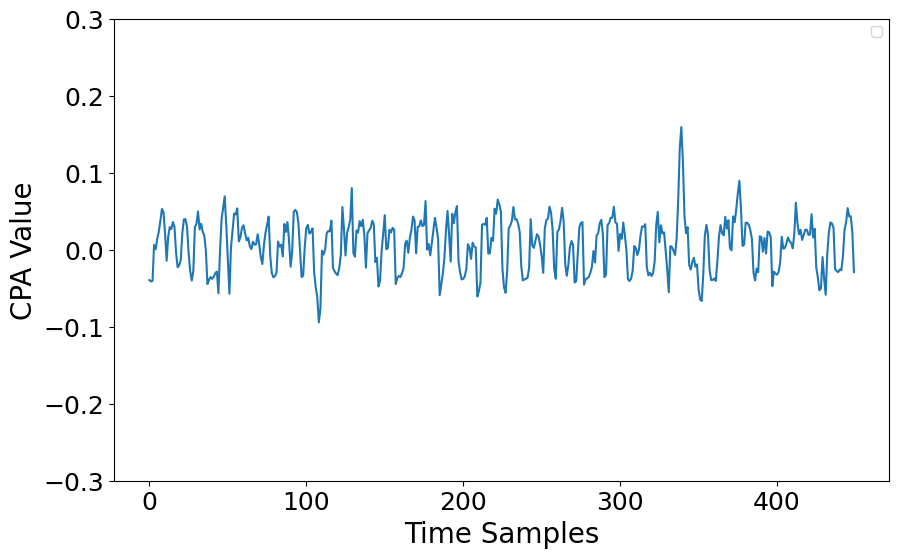

✅ CPA crosses threshold permanently at index 46 (≈ 480 traces)
Min traces: 480
  Byte 10 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:03<00:00, 324.92it/s] 


10
Shape of maxcpa_matrix: (100, 256)


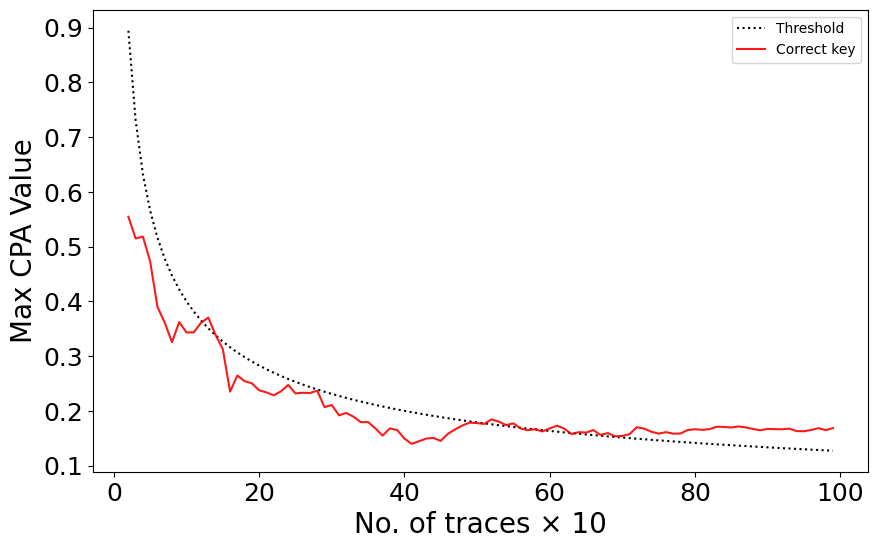

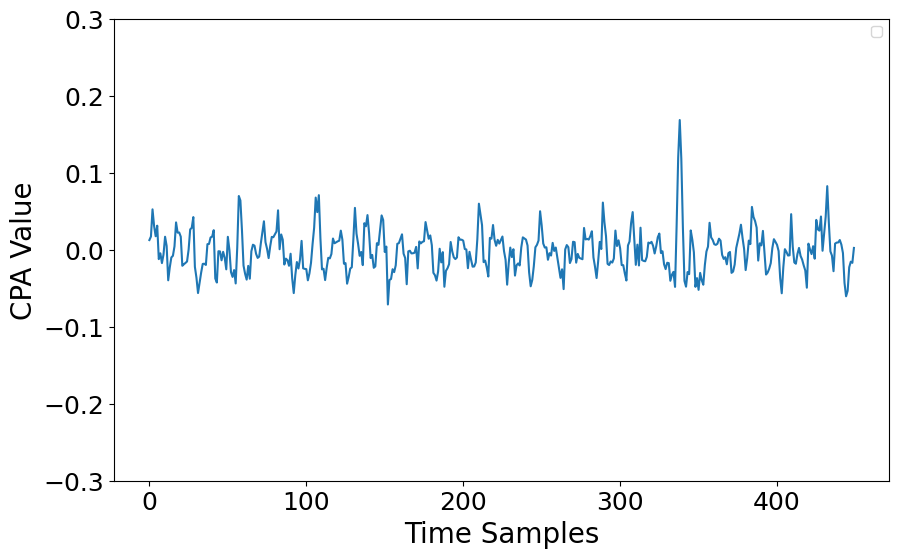

✅ CPA crosses threshold permanently at index 62 (≈ 640 traces)
Min traces: 640
  Byte 11 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:02<00:00, 357.07it/s] 

11
Shape of maxcpa_matrix: (100, 256)


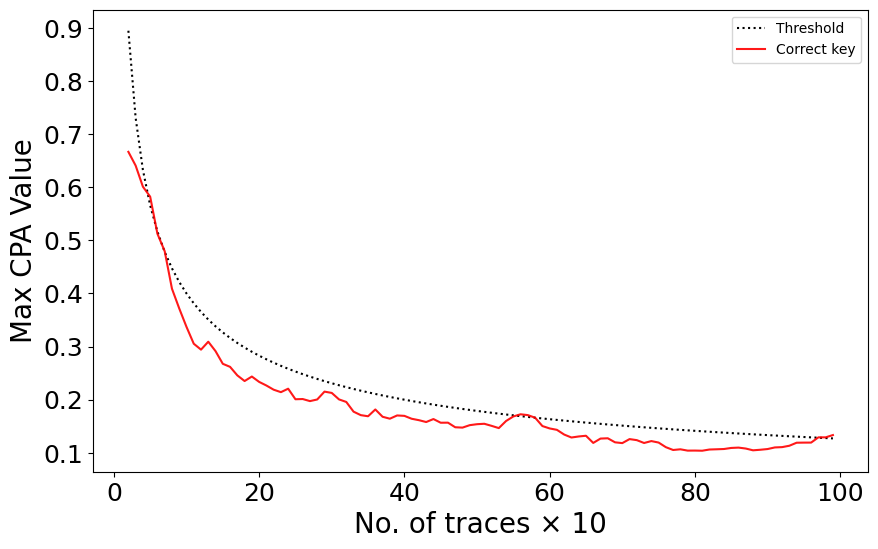

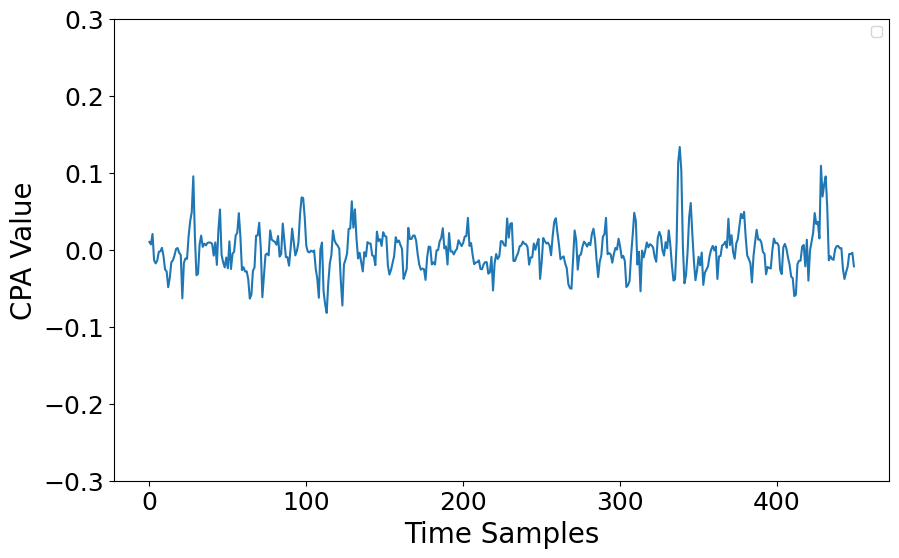

✅ CPA crosses threshold permanently at index 95 (≈ 970 traces)
Min traces: 970
  Byte 12 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:02<00:00, 350.40it/s] 

12
Shape of maxcpa_matrix: (100, 256)


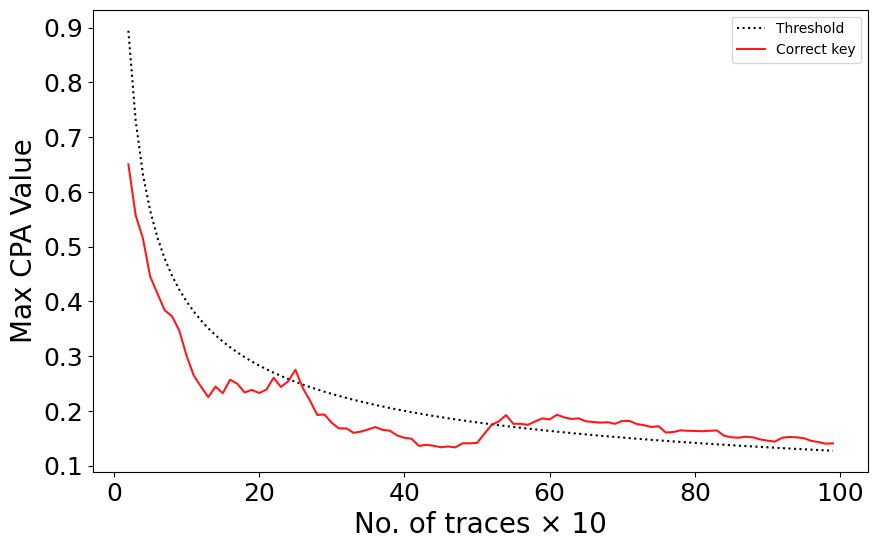

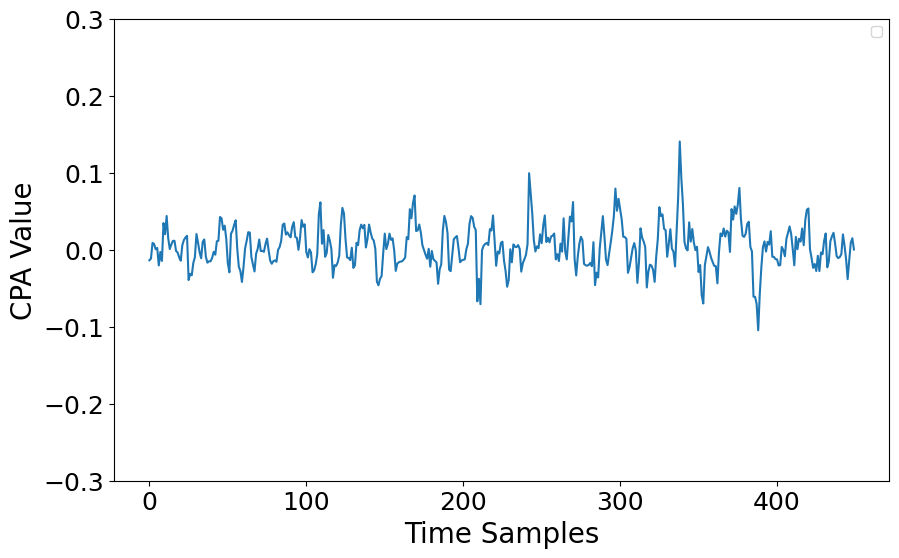

✅ CPA crosses threshold permanently at index 51 (≈ 530 traces)
Min traces: 530
  Byte 13 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:02<00:00, 352.57it/s] 


13
Shape of maxcpa_matrix: (100, 256)


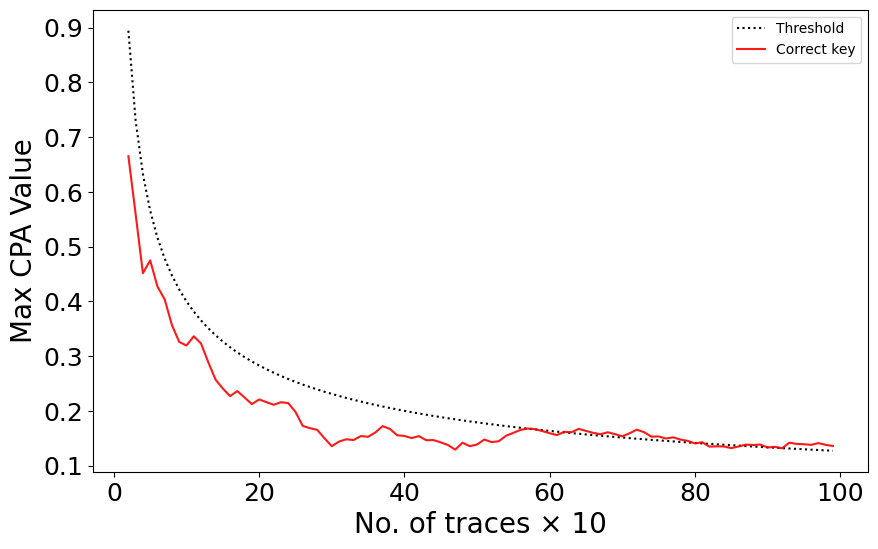

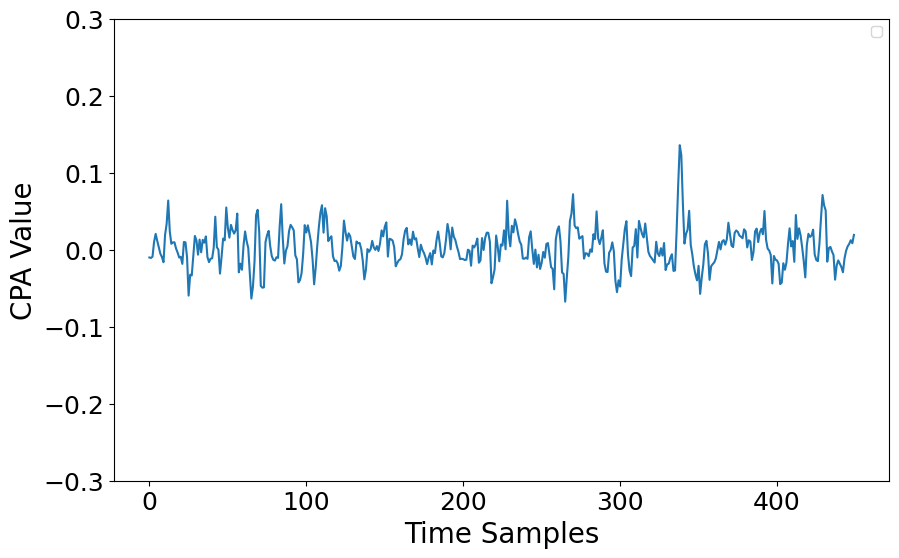

✅ CPA crosses threshold permanently at index 91 (≈ 930 traces)
Min traces: 930
  Byte 14 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:02<00:00, 355.49it/s] 


14
Shape of maxcpa_matrix: (100, 256)


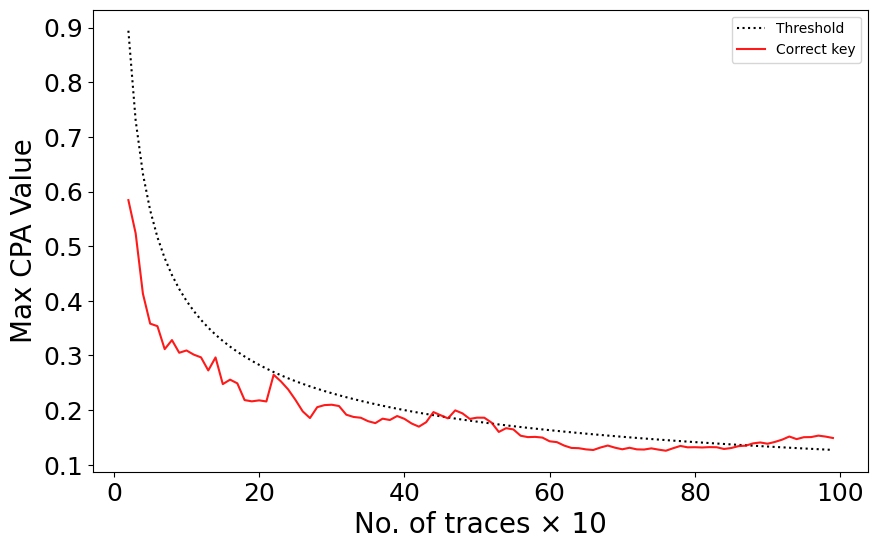

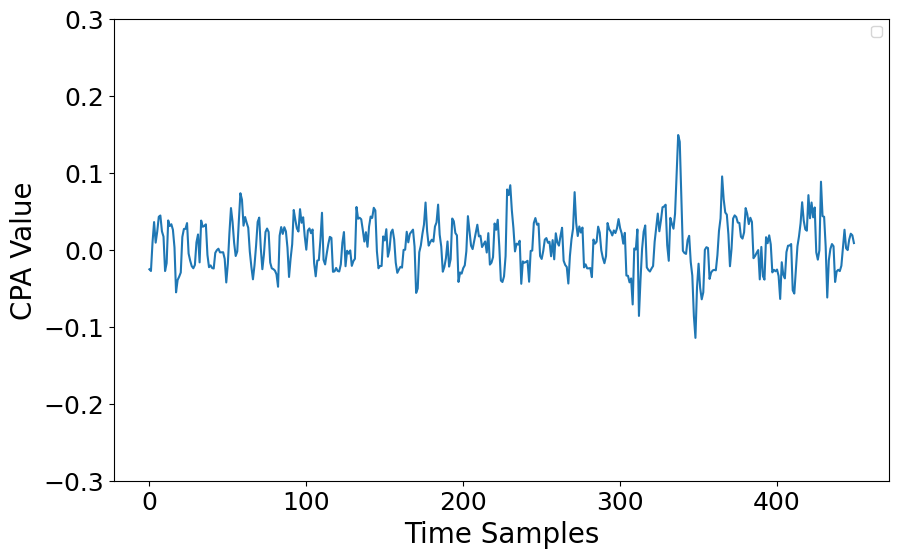

✅ CPA crosses threshold permanently at index 86 (≈ 880 traces)
Min traces: 880
  Byte 15 | Coord (6, 5) → (4, 5) ... 

100%|██████████| 999/999 [00:02<00:00, 362.52it/s] 


15
Shape of maxcpa_matrix: (100, 256)


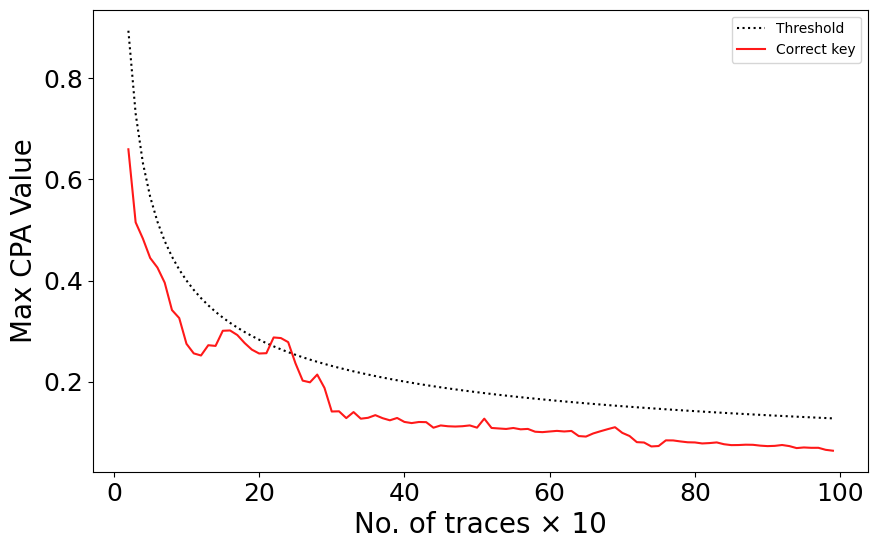

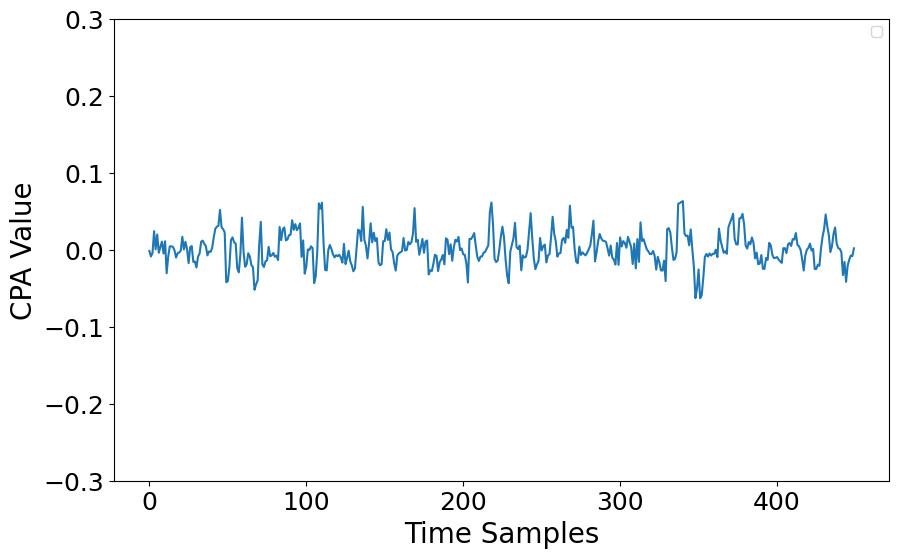

⚠️ CPA never stays permanently above the threshold.
Min traces: N/A

Summary of Minimum Traces per Location and Byte

Coord        Rotated      Byte   Min Traces     
----------------------------------------------------------------------
(6,5)        (4,5)        0      N/A            
(6,5)        (4,5)        1      N/A            
(6,5)        (4,5)        2      570            
(6,5)        (4,5)        3      N/A            
(6,5)        (4,5)        4      870            
(6,5)        (4,5)        5      580            
(6,5)        (4,5)        6      810            
(6,5)        (4,5)        7      N/A            
(6,5)        (4,5)        8      N/A            
(6,5)        (4,5)        9      480            
(6,5)        (4,5)        10     640            
(6,5)        (4,5)        11     970            
(6,5)        (4,5)        12     530            
(6,5)        (4,5)        13     930            
(6,5)        (4,5)        14     880            
(6,5)        (4,5)        1

In [15]:
# Uncomment and adjust the following to visualize CPA patterns at a specific grid location

# Select a high-MI location to analyze
# GRID_I, GRID_J = 5, 5  # Modify to select grid position


# Analyze CPA traces at specific grid locations for each byte
# Configure parameters below for UC vs FPGA

# ===== CONFIGURATION =====
# Select target: "UC" or "FPGA"
CPA_TARGET = TARGET

# Grid and coordinate settings
grid_size = (11, 11)
coords = [(6,5)]  # Grid locations to analyze,multiple locations can be supplied

# Byte range to analyze
byte_range = range(0, 16) #adjust this to decide for which numbers of the key you want to run CPA
source_experiment = test_avg  # Data source
num_traces = 1000



# ===== MODEL-SPECIFIC PARAMETERS =====
# Modify these parameters based on your target and leakage model

if CPA_TARGET == "UC":
    # UC Configuration
    rotation_n = 3
    num_traces = 1000
    
    # plot_CEMA_traces_temp parameters for UC
    cpa_params = {
        'div': 10,
        'visualize_correct': True,
        'model': 1,          # Change as needed for UC
        #(don't matter for model 1)
        'r1': 6,             # Bandwidth parameter 1
        'r2': 7,             # Bandwidth parameter 2
        'col_tar': 'sbb_o'   # Column target
    }
    
elif CPA_TARGET == "FPGA":
    # FPGA Configuration
#     source_experiment = test_avg  # Change to your FPGA data source
    rotation_n = 2
    
    # plot_CEMA_traces_temp parameters for FPGA
    cpa_params = {
        'div': 10,
        'visualize_correct': True,
        'model': 2,          # Change as needed for FPGA
        'r1': 6,             # round 1
        'r2': 7,             # round 2
        'col_tar': 'sbb_o'   # Column target
    }
else:
    raise ValueError(f"Unknown CPA_TARGET: {CPA_TARGET}")

# ===== EXECUTION =====
print(f"\nAnalyzing CPA traces for {CPA_TARGET}")
print(f"Coordinates: {coords}")
print(f"Grid size: {grid_size}")
print(f"Rotation parameter: {rotation_n}\n")

results = []
for byte_i in byte_range:
    for (x, y) in coords:
        i, j = reverse_coords_ccw(x, y, grid_size, rotation_n) #need to do this due to how the graphs are visualizaed and saved.
        print(f"  Byte {byte_i:2d} | Coord ({x}, {y}) → ({i}, {j})", end=' ... ')
        
        # Load traces
        temp_trace = source_experiment.get_dataset(f"random_{i}_{j}").read_all()
        
        # Compute CEMA
        m, c, f, min_traces = plot_CEMA_traces_temp(
            temp_trace,
            pt,  # Plaintext data
            num_traces,
            target_byte=byte_i,
            **cpa_params
        )
        
        results.append((x, y, i, j, min_traces, byte_i))
        print(f"Min traces: {int(min_traces) if min_traces is not None else 'N/A'}")

# ===== PRINT SUMMARY TABLE =====
print("\n" + "="*70)
print("Summary of Minimum Traces per Location and Byte")
print("="*70 + "\n")
print(f"{'Coord':<12} {'Rotated':<12} {'Byte':<6} {'Min Traces':<15}")
print("-" * 70)

for (x, y, i, j, min_traces, byte_i) in results:
    coord_str = f"({x},{y})"
    rot_str = f"({i},{j})"
    val_str = f"{int(min_traces)}" if min_traces is not None else "N/A"
    print(f"{coord_str:<12} {rot_str:<12} {byte_i:<6} {val_str:<15}")

print("\n" + "="*70)

## Optional: CEMA Heatmap (Correlation EM Analysis)

In [16]:
# # Compute CEMA heatmap across grid
# print("Computing CEMA correlation heatmap...")

# CEMA, CEMA_max = plot_CEMA_heatmap(
#     test,
#     pt,  
#     num=N_traces,
#     grid_size=n_steps,
#     rotation_n=rotation_n,
#     lower_b=35  # Sample range for correlation computation
# )

# print(f"CEMA computation complete")
# print(f"CEMA shape: {CEMA.shape}")
# print(f"Max CEMA correlation: {CEMA_max:.4f}")